# Importing libraries

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading & Inspection

In [182]:
titanic = sns.load_dataset("titanic")

In [183]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [184]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [185]:
titanic.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [186]:
print(titanic.isna().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [187]:
titanic.fillna({"age": titanic['age'].median()}, inplace=True)

In [188]:
print(titanic.isna().sum())

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [189]:
titanic.fillna({"embarked": titanic['embarked'].mode()[0]}, inplace=True)

In [190]:
titanic.drop(columns=["deck"], inplace=True)

In [191]:
titanic.dropna(subset=["embark_town"], inplace=True)

In [192]:
print(titanic.isna().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [193]:
titanic[['survived', 'alive']].value_counts()

,,count
survived,alive,
0,no,549
1,yes,340


Since the two features ('survived', 'alive') are the same, but we need the numeric one then we can drop the 'alive' column from the dataset.

In [194]:
titanic.drop(columns='alive', inplace=True)

In [195]:
titanic[['pclass', 'class']].value_counts()

,,count
pclass,class,
3,Third,491
1,First,214
2,Second,184


as before since the two features ('pclass', 'class') are the same, but we need the numeric one then we can drop the 'class' column from the dataset.

In [196]:
titanic.drop(columns='class', inplace=True)

In [197]:
titanic[['sex', 'who']].value_counts()

sex     who  
male    man      537
female  woman    269
        child     43
male    child     40
Name: count, dtype: int64

In [198]:
titanic[['who', 'adult_male']].value_counts()

,,count
who,adult_male,
man,True,537
woman,False,269
child,False,83


In [199]:
titanic[['sex', 'adult_male']].value_counts()

,,count
sex,adult_male,
male,True,537
female,False,312
male,False,40


In [200]:
titanic[['embarked', 'embark_town']].value_counts()

,,count
embarked,embark_town,
S,Southampton,644
C,Cherbourg,168
Q,Queenstown,77


Are the same too, but here we need to encode one of the two columns, then we can drop the two columns.

# Exploratory Data Analysis (EDA)

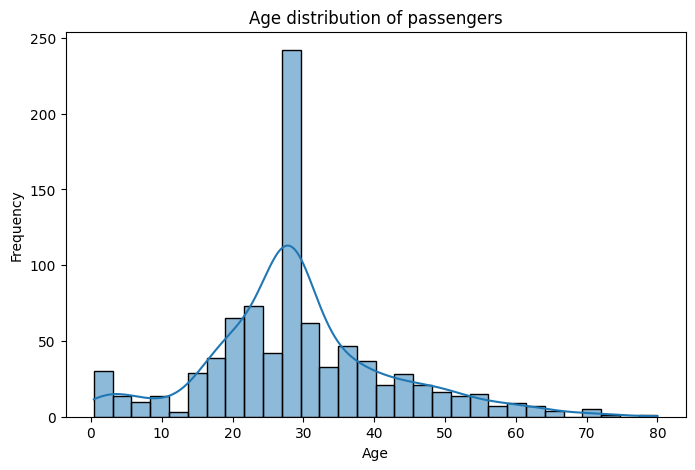

In [201]:
plt.figure(figsize=(8, 5))
sns.histplot(titanic['age'], bins=30, kde=True)
plt.title("Age distribution of passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

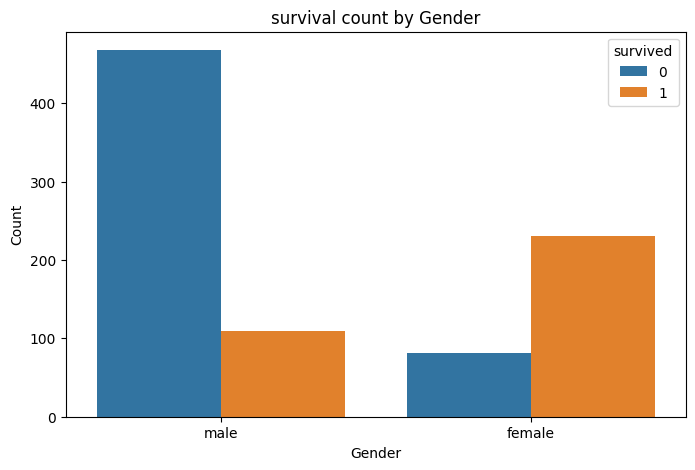

In [202]:
plt.figure(figsize=(8, 5))
sns.countplot(x="sex", hue="survived", data=titanic)
plt.title("survival count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

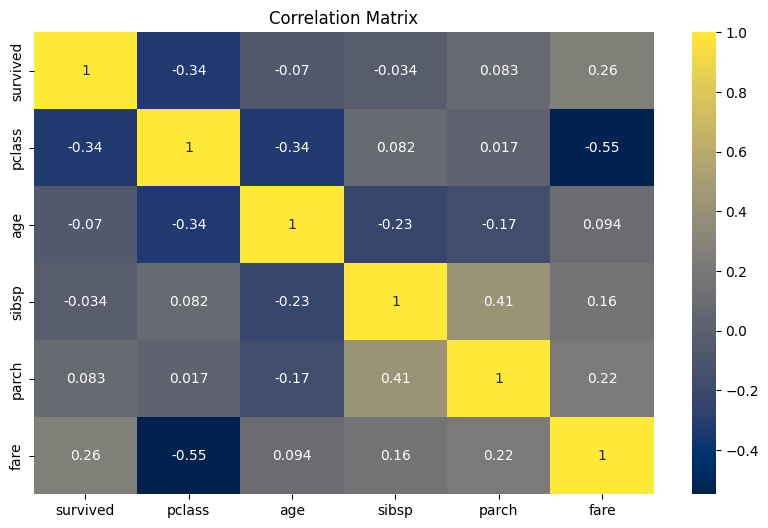

In [203]:
numerical_feastures = titanic.select_dtypes(include=["float64", "int64"])
corr = numerical_feastures.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap="cividis", annot=True)
plt.title("Correlation Matrix")
plt.show()

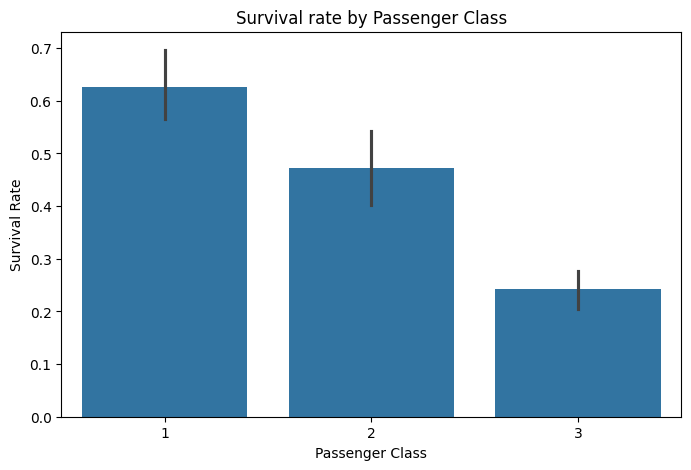

In [204]:
plt.figure(figsize=(8, 5))
sns.barplot(x="pclass", y="survived", data=titanic)
plt.title("Survival rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

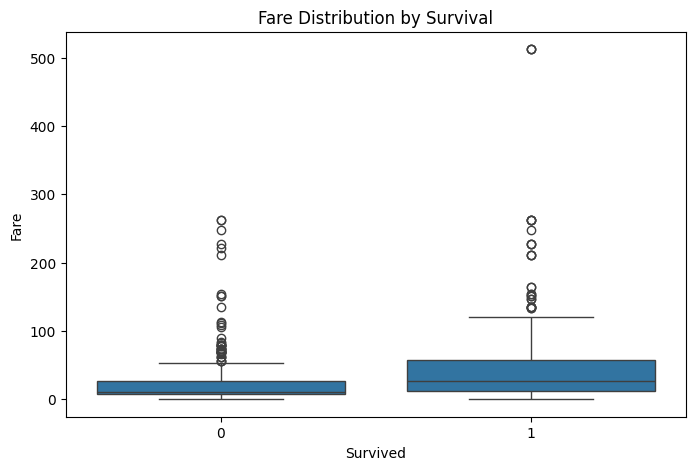

In [205]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="survived", y="fare", data=titanic)
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

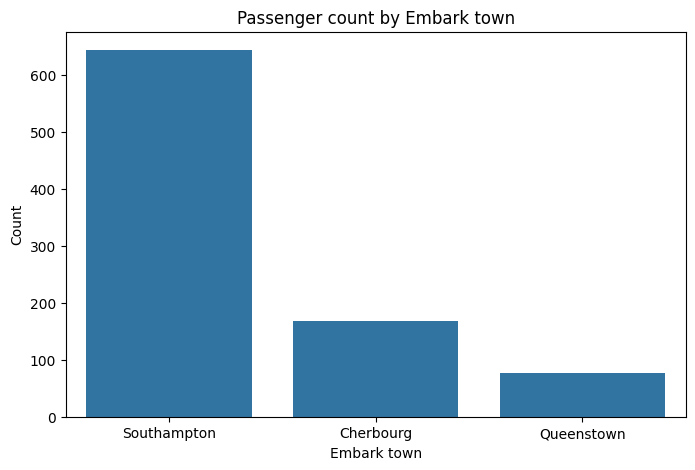

In [206]:
plt.figure(figsize=(8, 5))
sns.countplot(x='embark_town', data=titanic)
plt.title('Passenger count by Embark town')
plt.xlabel('Embark town')
plt.ylabel('Count')
plt.show()

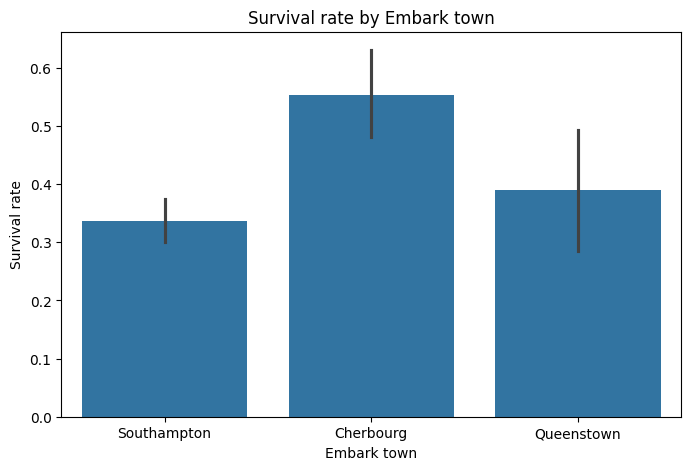

In [207]:
plt.figure(figsize=(8, 5))
sns.barplot(x='embark_town', y='survived', data=titanic)
plt.title('Survival rate by Embark town')
plt.xlabel('Embark town')
plt.ylabel('Survival rate')
plt.show()

# Feature Engineering

In [208]:
titanic["family_size"] = titanic['sibsp'] + titanic['parch']

In [209]:
titanic["is_alone"] = np.where(titanic["family_size"] > 0, 0, 1)

In [210]:
print(titanic[["family_size", "is_alone"]].head())

   family_size  is_alone
0            1         0
1            1         0
2            0         1
3            1         0
4            0         1


In [211]:
titanic[['alone', 'is_alone']].value_counts()

,,count
alone,is_alone,
True,1,535
False,0,354


as before since the two features ('alone', 'is_alone') are the same, but we need the numeric one then we can drop the 'alone' column from the dataset.

In [212]:
titanic.drop(columns='alone', inplace=True)

In [213]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,embark_town,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,Southampton,1,0
1,1,1,female,38.0,1,0,71.2833,C,woman,False,Cherbourg,1,0
2,1,3,female,26.0,0,0,7.9250,S,woman,False,Southampton,0,1
3,1,1,female,35.0,1,0,53.1000,S,woman,False,Southampton,1,0
4,0,3,male,35.0,0,0,8.0500,S,man,True,Southampton,0,1


In [214]:
sex_encoding = pd.get_dummies(titanic['sex'], prefix='sex')
titanic = pd.concat([titanic, sex_encoding], axis=1)
titanic.drop(columns='sex', inplace=True)

In [215]:
embark_town_encoding = pd.get_dummies(titanic['embark_town'], prefix='embarked')
titanic = pd.concat([titanic, embark_town_encoding], axis=1)
titanic.drop(columns=['embark_town', 'embarked'], inplace=True)

In [216]:
who_encoding = pd.get_dummies(titanic['who'], prefix='who')
titanic = pd.concat([titanic, who_encoding], axis=1)
titanic.drop(columns='who', inplace=True)

In [217]:
titanic.replace({True: 1, False: 0}, inplace=True)

/tmp/ipython-input-2269117105.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic.replace({True: 1, False: 0}, inplace=True)


In [218]:
titanic.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,family_size,is_alone,sex_female,sex_male,embarked_Cherbourg,embarked_Queenstown,embarked_Southampton,who_child,who_man,who_woman
0,0,3,22.0,1,0,7.2500,1,1,0,0,1,0,0,1,0,1,0
1,1,1,38.0,1,0,71.2833,0,1,0,1,0,1,0,0,0,0,1
2,1,3,26.0,0,0,7.9250,0,0,1,1,0,0,0,1,0,0,1
3,1,1,35.0,1,0,53.1000,0,1,0,1,0,0,0,1,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1,0,1,0,0,1,0,1,0


In [222]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   survived              889 non-null    int64  
 1   pclass                889 non-null    int64  
 2   age                   889 non-null    float64
 3   sibsp                 889 non-null    int64  
 4   parch                 889 non-null    int64  
 5   fare                  889 non-null    float64
 6   adult_male            889 non-null    int64  
 7   family_size           889 non-null    int64  
 8   is_alone              889 non-null    int64  
 9   sex_female            889 non-null    int64  
 10  sex_male              889 non-null    int64  
 11  embarked_Cherbourg    889 non-null    int64  
 12  embarked_Queenstown   889 non-null    int64  
 13  embarked_Southampton  889 non-null    int64  
 14  who_child             889 non-null    int64  
 15  who_man               889 no

# Additional Data Visualizations

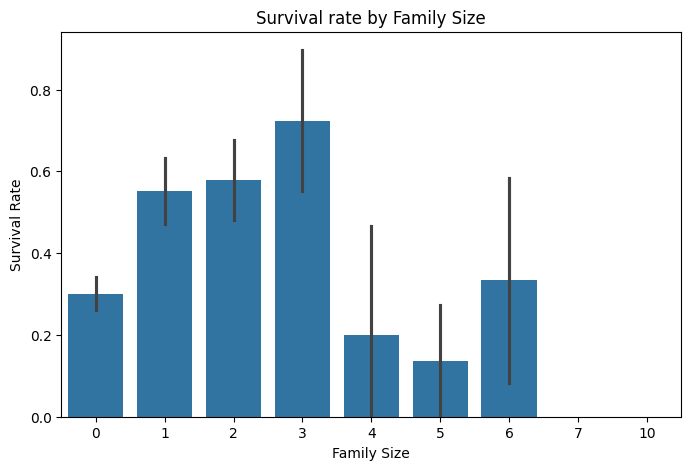

In [219]:
plt.figure(figsize=(8, 5))
sns.barplot(x="family_size", y="survived", data=titanic)
plt.title("Survival rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

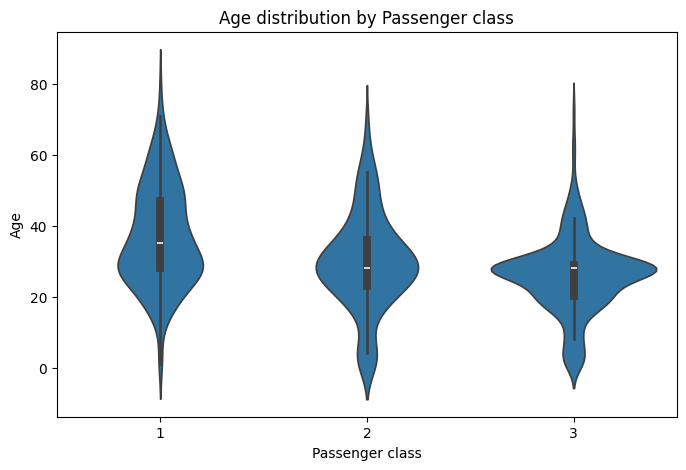

In [220]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='pclass', y='age', data=titanic)
plt.title('Age distribution by Passenger class')
plt.xlabel('Passenger class')
plt.ylabel('Age')
plt.show()

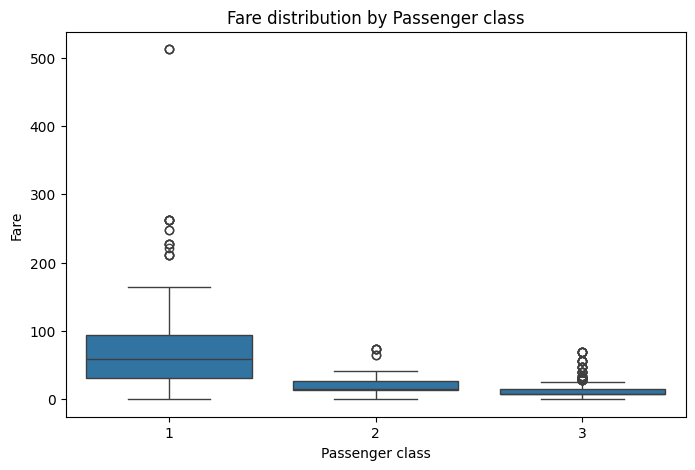

In [221]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='pclass', y='fare', data=titanic)
plt.title('Fare distribution by Passenger class')
plt.xlabel('Passenger class')
plt.ylabel('Fare')
plt.show()

# Summary of Analysis

*   **Age Distribution**: Most passengers were young adults, with a significant number of children and elderly individuals.

*   **Gender and Survival**: Women had a higher survival rate compared to men, reflecting the "women and children first" policy.

*   **Passenger Class and Survival**: First-class passengers had higher survival rates than those in lower classes, showing a class-based disparity in survival chances.

*   **Fare Influence**: Higher fare payments correlated with better survival odds, likely due to better access to lifeboats.
*   List item


*   **Family Size and Survival**: Moderate family sizes had higher survival rates; passengers traveling alone had lower survival chances.


*   **Embarkation Town**: Passengers who embarked at certain towns had varying survival rates, potentially reflecting different socioeconomic backgrounds.